# Freight Rate Prediction — Exploratory Data Analysis
Assessment: Machine Learning Engineer (Spotter)

Objectives of this notebook:
1. Understand the data structure of `train_test.csv`
2. Identify data quality issues (missing values, anomalies)
3. Understand the relationship between features and the target variable (`posted_rate`)
4. Determine the train/validation split strategy and feature engineering pipeline prior to modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 110

train = pd.read_csv('data/train-test.csv')
val = pd.read_csv('data/validation.csv')
dec_inputs = pd.read_csv('data/december-chart-inputs.csv')

train['date'] = pd.to_datetime(train['date'])
val['date'] = pd.to_datetime(val['date'])
dec_inputs['date'] = pd.to_datetime(dec_inputs['date'])

print("train_test.csv :", train.shape)
print("validation.csv :", val.shape)
print("december_chart_inputs.csv:", dec_inputs.shape)
train.head()

Matplotlib is building the font cache; this may take a moment.


FileNotFoundError: [Errno 2] No such file or directory: 'data/train-test.csv'

### Data Dictionary: Freight Pricing Dataset

This document provides a detailed explanation of each feature (column) in the dataset. These features are grouped based on their operational functions in logistics.

#### 1. Prediction Target (Label)
* **`posted_rate`** (`float64`): The actual freight rate or final price paid to transport the load on a specific route. This is the primary target variable to be predicted by the machine learning model.

#### 2. Identification & Basic Logistics
* **`load_id`** (`object`): A unique identifier for each shipment transaction (e.g., `TR-000001`). This feature is used strictly for row identification and is typically dropped during modeling as it carries no predictive value.
* **`equipment`** (`object`): The type of truck or equipment required for the load (e.g., `Dry Van`, `Reefer`). This categorical feature is important because different equipment types have distinct operational cost structures.
* **`weight`** (`float64`): The total weight of the shipped goods. This parameter influences operational costs, as heavier loads result in higher fuel consumption.

#### 3. Location & Geospatial
* **`pickup`** (`object`): The text name of the origin city (pickup location).
* **`delivery`** (`object`): The text name of the destination city (drop-off location).
* **`pickup_lat` & `pickup_lon`** (`float64`): Spatial coordinates (latitude and longitude) for the pickup location.
* **`delivery_lat` & `delivery_lon`** (`float64`): Spatial coordinates (latitude and longitude) for the delivery location. Machine learning algorithms can learn spatial patterns and regional variations more effectively from coordinates than from raw city names.
* **`distance`** (`float64`): The travel distance between the pickup and delivery points. This feature is typically one of the strongest predictors (independent variables) in determining freight rates.

#### 4. Temporal & Seasonality
* **`date`** (`datetime64[ns]`): The date on which the load was posted or scheduled (e.g., `2025-01-01`). This column is used to extract temporal features (e.g., day of week, month) to capture seasonal price fluctuations.

#### 5. External Indicators
* **`market_index`** (`float64`): A macro-level metric representing the logistics market condition (supply and demand balance for trucks) on that given day. It indicates market tightness and truck availability.
* **`quote_signal`** (`float64`): A numerical benchmark signal or base rate estimate derived from external systems or third-party data to serve as a market reference.

## 1. Data Structures & Missing Values

In [6]:
print("=== dtypes ===")
print(train.dtypes)
print()
print("=== missing values (train) ===")
print(train.isna().sum())
print()
print("=== missing values (validation) ===")
print(val.isna().sum())
print()
print("=== duplicate load_id ===")
print("train:", train['load_id'].duplicated().sum(), " | val:", val['load_id'].duplicated().sum())
print("=== fully duplicate rows (excl load_id) ===")
print(train.duplicated(subset=[c for c in train.columns if c != 'load_id']).sum())

=== dtypes ===
load_id                 object
pickup                  object
delivery                object
pickup_lat             float64
pickup_lon             float64
delivery_lat           float64
delivery_lon           float64
distance               float64
equipment               object
weight                 float64
date            datetime64[ns]
market_index           float64
quote_signal           float64
posted_rate            float64
dtype: object

=== missing values (train) ===
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

=== missing values (validation) ===
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment      

**Key Findings:**
- `weight` is missing in 300 rows (0.6%) of the training set and 165 rows in the validation set.
- `market_index` is missing in 374 rows (0.8%) of the training set and 249 rows in the validation set — evenly distributed across months (~0.7–0.9%), indicating a **Missing at Random (MAR)** pattern rather than a specific period anomaly.
- No duplicate `load_id` values or fully identical duplicate rows were found.
- **`december_chart_inputs.csv` DOES NOT contain the `market_index` and `quote_signal` columns** — Crucial takeaway: The final model must either be able to run without these two features or rely on an estimation/imputation strategy to remove direct dependency on them for the December prediction scenario.

## 2. Variabel Target: `posted_rate`

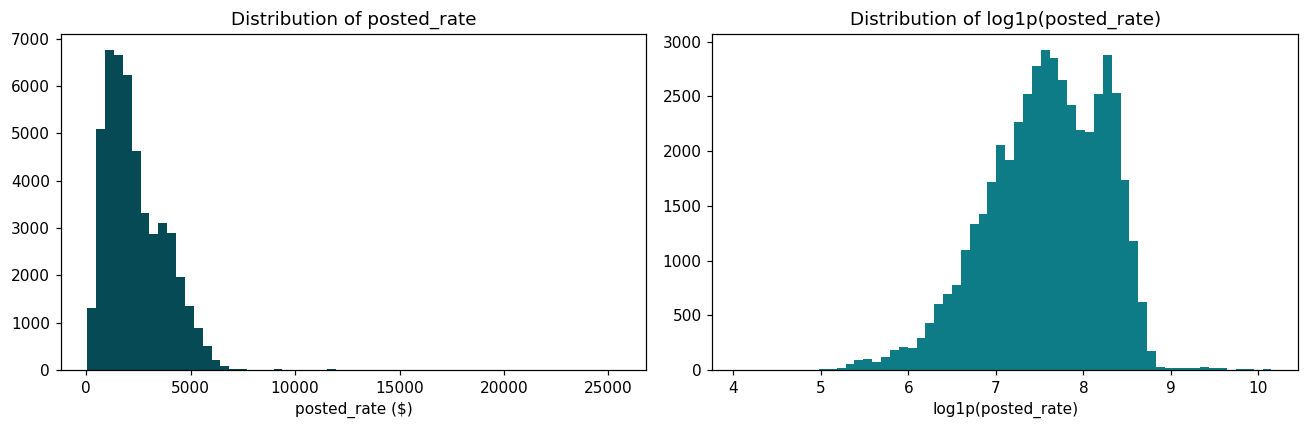

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['posted_rate'], bins=60, color='#064A56')
axes[0].set_title('Distribution of posted_rate')
axes[0].set_xlabel('posted_rate ($)')

axes[1].hist(np.log1p(train['posted_rate']), bins=60, color='#0E7C86')
axes[1].set_title('Distribution of log1p(posted_rate)')
axes[1].set_xlabel('log1p(posted_rate)')
plt.tight_layout()
plt.show()

print(train['posted_rate'].describe())

**Key Findings:**
- `posted_rate` is right-skewed (typical for pricing data) — applying a log transformation makes its distribution significantly closer to a normal distribution. This provides a strong signal to **train the model on `log1p(posted_rate)`** and apply `expm1` during prediction. This prevents the model from being overly influenced by high-cost long-haul routes and helps keep prediction errors proportional (especially relevant if evaluation uses metrics like MAPE or RMSE on the original scale).

## 3. Numerical Features: distance, weight, market_index, quote_signal

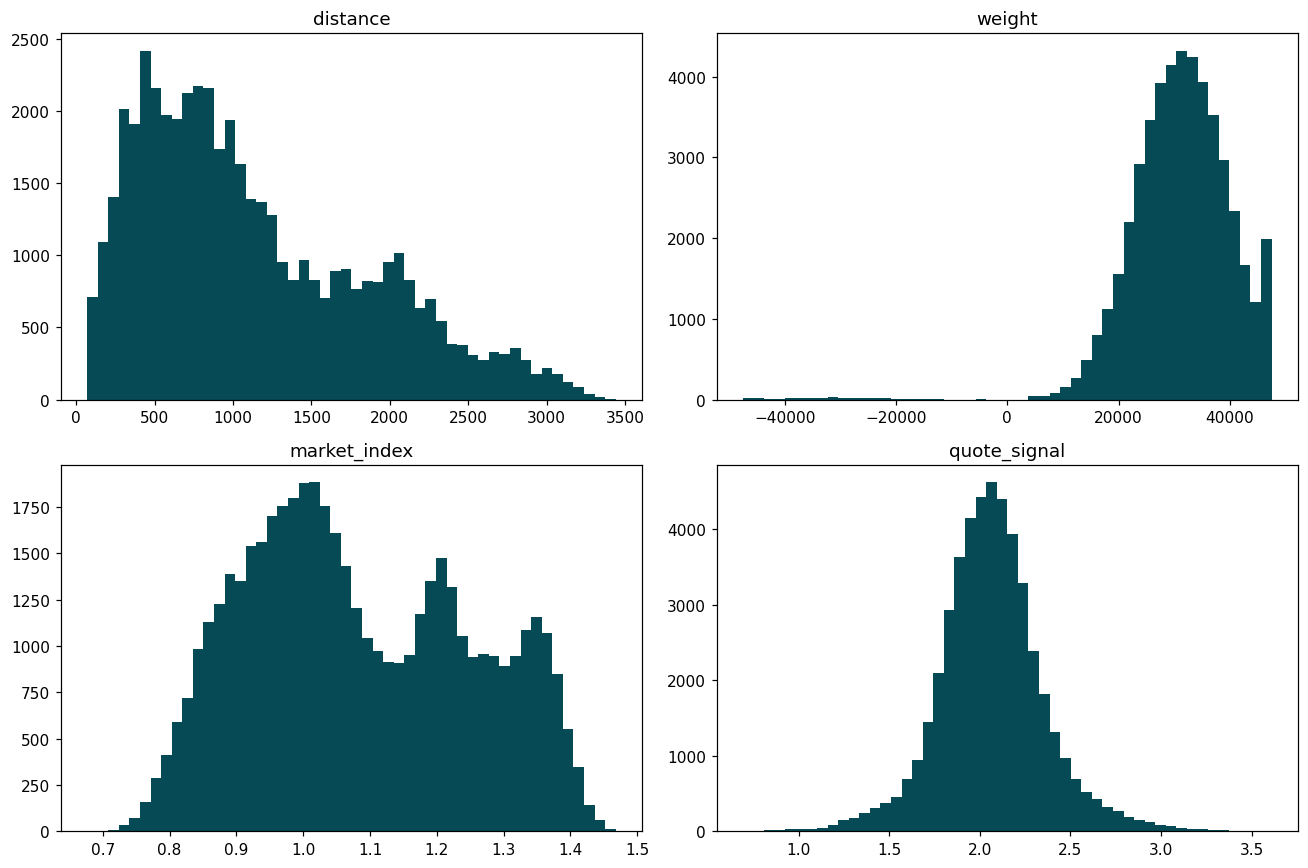

,distance,weight,market_index,quote_signal
count,48000.000000,47700.000000,47626.000000,48000.000000
mean,1135.856654,31028.844004,1.083387,2.062468
std,728.564416,9391.440620,0.168091,0.291391
min,70.000000,-47500.000000,0.676390,0.692280
25%,550.400000,25800.000000,0.949670,1.891030
50%,953.300000,31436.500000,1.055800,2.055750
75%,1645.525000,37018.000000,1.219590,2.221685
max,3439.800000,47500.000000,1.467780,3.610350


In [9]:
num_cols = ['distance', 'weight', 'market_index', 'quote_signal']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, num_cols):
    ax.hist(train[col].dropna(), bins=50, color='#064A56')
    ax.set_title(col)
plt.tight_layout()
plt.show()

train[num_cols].describe()

In [10]:
print("Weight <= 0:", (train['weight'] <= 0).sum(), "out of", train['weight'].notna().sum(), "non-null values")
neg = train.loc[train['weight'] < 0, 'weight'].abs()
pos = train.loc[train['weight'] > 0, 'weight']
print("\nDistribution of |weight| for NEGATIVE rows:\n", neg.describe())
print("\nDistribution of weight for POSITIVE rows:\n", pos.describe())

Weight <= 0: 292 out of 47700 non-null values

Distribution of |weight| for NEGATIVE rows:
 count      292.000000
mean     31724.195205
std       8262.536326
min       5000.000000
25%      25928.500000
50%      31821.500000
75%      37284.250000
max      47500.000000
Name: weight, dtype: float64

Distribution of weight for POSITIVE rows:
 count    47408.000000
mean     31415.358674
std       7994.902979
min       5000.000000
25%      25922.000000
50%      31493.500000
75%      37063.000000
max      47500.000000
Name: weight, dtype: float64


**Data Quality Issue #1 — Negative `weight` values.**
There are 292 rows (0.6%) with negative `weight` values (e.g., -36,559). The distribution of absolute magnitudes for these negative rows is **identical** to that of the positive rows (mean ~31.7k vs. ~31.4k, with the same range of 5,000–47,500). This indicates a **sign error** during data entry or ingestion rather than actual outliers — likely caused by a source system bug prepending negative signs.

**Handling:**
- Take the absolute value (`abs(weight)`).
- Impute remaining missing values (NaN) using the median grouped by `equipment` type, as cargo weight strongly correlates with truck category.

In [11]:
def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

train['hav_distance'] = haversine(train.pickup_lat, train.pickup_lon, train.delivery_lat, train.delivery_lon)
train['dist_ratio'] = train['distance'] / train['hav_distance']

print("Distance (road) / haversine (straight-line) ratio:")
print(train['dist_ratio'].describe())
print("\nNumber of rows with reasonable ratio (1.05 - 1.35, normal road circuity factor):",
      ((train['dist_ratio'] >= 1.05) & (train['dist_ratio'] <= 1.35)).sum(), "/", len(train))
print("Number of rows with anomalous ratio (>2):", (train['dist_ratio'] > 2).sum())
train.sort_values('dist_ratio', ascending=False)[['pickup','delivery','distance','hav_distance','dist_ratio']].head(5)

Distance (road) / haversine (straight-line) ratio:
count    48000.000000
mean         1.194681
std          0.143541
min          1.058090
25%          1.164765
50%          1.182231
75%          1.204765
max          9.634919
Name: dist_ratio, dtype: float64

Number of rows with reasonable ratio (1.05 - 1.35, normal road circuity factor): 47182 / 48000
Number of rows with anomalous ratio (>2): 22


,pickup,delivery,distance,hav_distance,dist_ratio
37183,Shreveport,New Orleans,70.0,7.26524,9.634919
46059,Shreveport,New Orleans,70.0,7.26524,9.634919
6960,New Orleans,Shreveport,70.0,7.26524,9.634919
15756,Shreveport,New Orleans,70.0,7.26524,9.634919
38469,Shreveport,New Orleans,70.0,7.26524,9.634919


**Data Quality Issue #2 — A few routes with `distance` inconsistent with coordinates.**
98% of rows have a road-to-geodesic distance ratio of 1.05–1.35x (typical for US highways). However, 22 rows (0.05%) exhibit extreme ratios (>2x, up to 9.6x) — for example, the Shreveport↔New Orleans route pair where the coordinates are very close, but `distance` is recorded as 70 miles. This is likely a **distance input error** for a few specific routes.

**Handling:** Since the proportion is extremely small (<0.05%) and `distance` is a high-magnitude, highly dominant feature, these rows are retained (not removed, to avoid losing route combinations) and left to the robustness of tree-based models (which are naturally resilient to a few outliers). Noted as a known issue in the report.

In [12]:
rpm = train['posted_rate'] / train['distance']
print("Rate-per-mile stats:")
print(rpm.describe())
print("\nRows with rate-per-mile > 10 (extreme):", (rpm > 10).sum())
train.loc[rpm > 10, ['pickup','delivery','distance','weight','equipment','posted_rate']].assign(rpm=rpm[rpm>10]).head(10)

Rate-per-mile stats:
count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
dtype: float64

Rows with rate-per-mile > 10 (extreme): 49


,pickup,delivery,distance,weight,equipment,posted_rate,rpm
870,Tulsa,Baton Rouge,305.6,26447.0,Reefer,4069.24,13.315576
1415,Montgomery,Birmingham,198.2,25383.0,Reefer,2509.96,12.663774
2469,Tucson,Albuquerque,441.5,47369.0,Flatbed,4989.66,11.301608
4489,Dayton,Harrisburg,476.7,44942.0,Dry Van,5048.45,10.590413
6078,Cincinnati,Lexington,150.4,20990.0,Reefer,1550.14,10.306782
7841,Raleigh,Greensboro,353.0,28610.0,Reefer,4368.67,12.375836
9999,Grand Rapids,Boston,1069.1,29476.0,Reefer,10769.23,10.073174
10173,Chattanooga,Mobile,307.9,30742.0,Flatbed,3624.74,11.772459
11362,Providence,New York,361.0,43114.0,Dry Van,3760.75,10.417590
11713,Fort Wayne,Oklahoma City,1151.3,38377.0,Reefer,12454.19,10.817502


**Data Quality Issue #3 — Rate-per-mile outliers.**
49 rows (0.1%) have a rate-per-mile far above normal (average ~2.2, reaching up to 14+) — mostly on short-haul routes (<650 miles) which typically have higher rate-per-mile due to fixed pickup/delivery costs, but some are still beyond reasonable bounds. These are candidates for price outliers/anomalies; they will be handled via **light capping (winsorizing)** on the target during training or through the use of models robust to outliers (tree-based models, Huber/quantile loss).

## 4. Categorical Features: equipment, city

equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

Average rate-per-mile per equipment:
equipment
Dry Van    2.115401
Flatbed    2.294729
Reefer     2.383376
dtype: float64


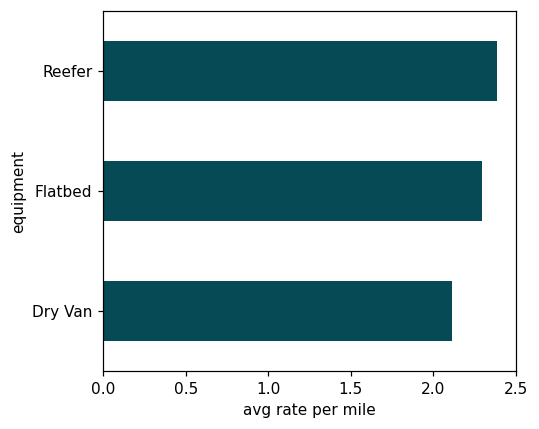

In [13]:
print(train['equipment'].value_counts())
print()
rpm_by_eq = (train['posted_rate']/train['distance']).groupby(train['equipment']).mean().sort_values()
print("Average rate-per-mile per equipment:")
print(rpm_by_eq)

fig, ax = plt.subplots(figsize=(5,4))
rpm_by_eq.plot(kind='barh', ax=ax, color='#064A56')
ax.set_xlabel('avg rate per mile')
plt.tight_layout()
plt.show()

In [14]:
cities_train = set(train['pickup']) | set(train['delivery'])
cities_val = set(val['pickup']) | set(val['delivery'])
print("Number of unique cities in train:", len(cities_train))
print("Number of unique cities in validation:", len(cities_val))
print("Cities that ONLY appear in validation (not in train):", cities_val - cities_train)

Number of unique cities in train: 64
Number of unique cities in validation: 72
Cities that ONLY appear in validation (not in train): {'Allentown', 'Charlotte', 'Chicago', 'Norfolk', 'Knoxville', 'Jackson', 'Laredo', 'San Diego'}


**Key Finding:** There are 8 cities (Allentown, Jackson, Charlotte, Norfolk, Chicago, San Diego, Laredo, Knoxville) that appear in `validation.csv` but **never appear** in `train_test.csv`. This means city-based categorical encoding (e.g., one-hot or target encoding per city) will result in *unseen categories* during validation inference.

**Feature Engineering Implications:** Do not overly rely on city identity as discrete categories. It is safer to use features derived from coordinates (`pickup_lat/lon`, `delivery_lat/lon`) — such as regions (lat/lon grids), geographical direction, or simply allowing tree-based models to capture generalized patterns directly from lat/lon, distance, and equipment, rather than memorizing city names.

## 5. Correlation Between Numeric Features vs Target

posted_rate     1.000000
distance        0.908519
weight          0.034840
market_index    0.034165
quote_signal   -0.039858
Name: posted_rate, dtype: float64


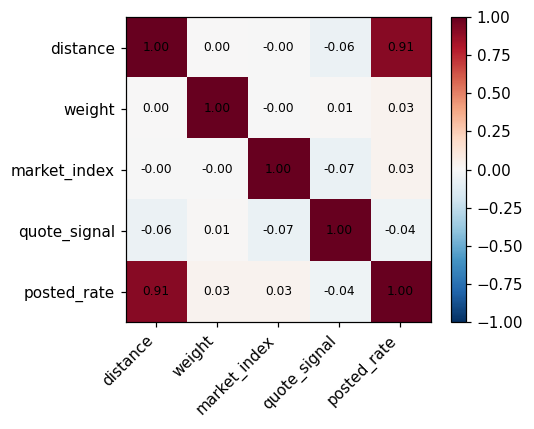

In [ ]:
corr_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']
corr = train[corr_cols].corr()
print(corr['posted_rate'].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im)

plt.tight_layout()
plt.show()

**Key Finding:** `distance` dominates (correlation ~0.91 with `posted_rate`) — makes sense, as freight rates are primarily a function of distance. `weight`, `market_index`, and `quote_signal` have small direct linear correlations (<0.05), but this does not necessarily mean they are useless — we will check their contribution beyond the effect of `distance`.

In [15]:
from numpy.linalg import lstsq
X = np.vstack([train['distance'], np.ones(len(train))]).T
coef, *_ = lstsq(X, train['posted_rate'], rcond=None)
resid = train['posted_rate'] - X @ coef

mask = train['market_index'].notna()
print("Correlation of RESIDUALS (posted_rate after removing distance effect) with:")
print("  market_index :", np.corrcoef(resid[mask], train.loc[mask,'market_index'])[0,1].round(3))
print("  quote_signal :", np.corrcoef(resid, train['quote_signal'])[0,1].round(3))
mask_w = train['weight'].notna()
print("  weight       :", np.corrcoef(resid[mask_w], train.loc[mask_w,'weight'])[0,1].round(3))
print("  Reefer flag  :", np.corrcoef(resid, (train['equipment']=='Reefer').astype(int))[0,1].round(3))
print("  Flatbed flag :", np.corrcoef(resid, (train['equipment']=='Flatbed').astype(int))[0,1].round(3))

Correlation of RESIDUALS (posted_rate after removing distance effect) with:
  market_index : 0.086
  quote_signal : 0.029
  weight       : 0.078
  Reefer flag  : 0.169
  Flatbed flag : 0.059


**Key Finding:** After removing the effect of `distance`, `equipment` (specifically Reefer) shows the clearest contribution to the remaining price variance (Reefer & Flatbed have a higher rate-per-mile than Dry Van — which makes sense as refrigerated and flatbed trucks are more expensive to operate). `market_index` also exhibits a small but consistent contribution. `weight` and `quote_signal` have very small marginal contributions linearly, but they potentially interact non-linearly with other features (which tree-based/GBM models can capture, unlike simple linear correlation).

## 6. Seasonal/Time Patterns (important for December forecasts)

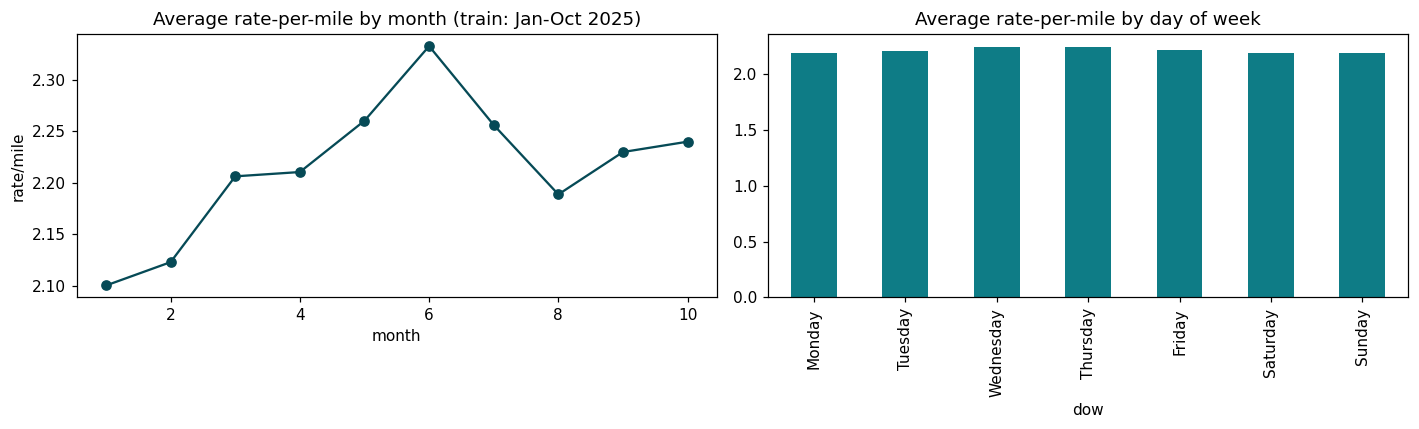

            rpm  market_index
month                        
1      2.100221      0.926696
2      2.122885      0.995997
3      2.206132      1.072880
4      2.210309      1.207649
5      2.260106      1.301452
6      2.332484      1.280316
7      2.255952      1.200893
8      2.188584      0.981480
9      2.229725      0.893039
10     2.239763      0.957502


In [16]:
train['month'] = train['date'].dt.month
train['dow'] = train['date'].dt.day_name()
train['rpm'] = train['posted_rate'] / train['distance']

fig, axes = plt.subplots(1, 2, figsize=(13,4))
train.groupby('month')['rpm'].mean().plot(ax=axes[0], marker='o', color='#064A56')
axes[0].set_title('Average rate-per-mile by month (train: Jan-Oct 2025)')
axes[0].set_xlabel('month'); axes[0].set_ylabel('rate/mile')

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
train.groupby('dow')['rpm'].mean().reindex(dow_order).plot(kind='bar', ax=axes[1], color='#0E7C86')
axes[1].set_title('Average rate-per-mile by day of week')
plt.tight_layout()
plt.show()

print(train.groupby('month')[['rpm','market_index']].mean())

**Key Findings:**
- There is a clear **seasonal trend**: rate-per-mile increases from January → peaks around May–June → declines again towards September–October. `market_index` follows a similar pattern (rising then falling), consistent with the annual freight demand cycle common in the industry (summer typically sees higher volume).
- There is a small but consistent day-of-week effect (Wednesday/Thursday are slightly higher than weekends).
- **Training data ends on October 31, 2025**, whereas validation and December predictions fall in **November–December 2025** — a period with no representation in the training set. This means the model **must extrapolate** this seasonal trend. Solution: Encode dates as cyclical features (`sin`/`cos` of day-of-year) so the model can capture repeating seasonal patterns and generalize to unseen months, rather than using `month` as discrete categories (which never take values of 11/12 during training).

## 7. Validation of the Train Set vs. Validation Set vs. December Input Data

In [17]:
print("Train date range          :", train['date'].min().date(), "-", train['date'].max().date())
print("Validation date range     :", val['date'].min().date(), "-", val['date'].max().date())
print("December date range       :", dec_inputs['date'].min().date(), "-", dec_inputs['date'].max().date())
print()
print("Train columns       :", train.columns.tolist())
print("Validation columns  :", val.columns.tolist())
print("December columns    :", dec_inputs.columns.tolist())
print()
print("December inputs — all rows for Lexington->Fort Wayne route, checking consistency of fixed fields:")
print(dec_inputs[['pickup','delivery','distance','equipment','weight']].drop_duplicates())

Train date range          : 2025-01-01 - 2025-10-31
Validation date range     : 2025-11-01 - 2025-12-31
December date range       : 2025-12-01 - 2025-12-31

Train columns       : ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate', 'hav_distance', 'dist_ratio', 'month', 'dow', 'rpm']
Validation columns  : ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']
December columns    : ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']

December inputs — all rows for Lexington->Fort Wayne route, checking consistency of fixed fields:
      pickup    delivery  distance equipment  weight
0  Lexington  Fort Wayne       360   Dry Van   32000


**Schema Conclusion:**
- Train (Jan–Oct 2025) and Validation (Nov–Dec 2025) **do not overlap in time at all** → this points toward a **time-based split** strategy for internal validation (instead of a random split), ensuring our validation mirrors real-world conditions: the model is trained on past data and tested on future extrapolation.
- `december_chart_inputs.csv` contains only 7 columns (without `pickup_lat/lon`, `delivery_lat/lon`, `market_index`, or `quote_signal`) — the final model for the December scenario **must be able to run without these features**. Coordinates for Lexington & Fort Wayne can be looked up from the train/validation data (since they already appear there), allowing geographical features to be reconstructed; however, `market_index`/`quote_signal` are completely unavailable for December → strategy: train **two feature variants** (full-feature for `validation.csv`, reduced-feature/imputed-trend for the December scenario), or train a single model that does not heavily rely on those two features and imputes their values using seasonal trend estimates when needed.

## 8. Summary of Findings → Modeling Plan

**Data quality issues & handling:**
1. Negative `weight` (292 rows) → sign error, take `abs()`.
2. Missing `weight` & `market_index` (~0.6–0.8%) → imputation (median per equipment / monthly trend).
3. 22 rows with `distance` inconsistent with coordinates → retained (very small quantity), tree-based models are robust to this.
4. 49 extreme rate-per-mile rows → light capping / robust loss during training.
5. 8 new cities in validation missing from train → avoid overfitting to city identity, rely on geographical features (lat/lon) + distance + equipment.

**Feature engineering plan:**
- `distance`, `weight` (cleaned), `equipment` (one-hot)
- Cyclical date features: `sin(2π·doy/365)`, `cos(2π·doy/365)`, `dayofweek`
- `market_index`, `quote_signal` (with imputation for missing rows / December scenario)
- Pickup/delivery coordinates (for generalization to new cities), optional haversine distance as a complementary feature to `distance`

**Target:** `log1p(posted_rate)` → `expm1` during inverse prediction.

**Split strategy:** Time-based split (not random) — e.g., the first 80% (Jan–Aug) for training, the last 20% (Sep–Oct) for internal validation — so that evaluation reflects the actual task (extrapolating to Nov–Dec).

**Candidate models:** Gradient Boosting (LightGBM/XGBoost) as the primary model — robust to outliers, handles non-linear feature interactions (equipment × distance × season) without manual scaling, and natively handles missing values.